In [1]:
import gymnasium as gym
import numpy as np
import math
import os
import configparser
from sb3_contrib.ppo_mask import MaskablePPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
import matplotlib.pyplot as plt
from sb3_contrib.common.maskable.utils import get_action_masks
from src.bin_packing import best_fit_on_test_workload


In [2]:
from src.hpc_env import HPCenv
from src.validation import Validation
from src.baseline import PercentileBaseline
from src.utils import mask_fn, get_config_as_dict
from src.carbon_intensity import CarbonIntensity

In [3]:

# Load config with explicit path and typed parsing
config = configparser.ConfigParser()
config_path = os.path.join(os.getcwd(), 'config_file', 'config.ini')
config.read(config_path)

['/Users/mikkeldahl/green-hpc-scheduler/config_file/config.ini']

## Model validation

In [11]:
val = Validation()
val.load_dir("results/train_and_eval/eta_0.5_optimal")
processed_stats_baselines, raw_stats_baselines = val.run_baselines(n_eval_episodes=1, mode="validation")

Executing baseline:  FCFS Baseline
Episode  0
Current secounds after start:  3520255
3482
Current secounds after start:  6603248
6895
Executing baseline:  10-percentile Baseline
Episode  0
Current secounds after start:  2261288
1209
Current secounds after start:  4557771
1919
Current secounds after start:  6943692
2271
Current secounds after start:  9639465
2658
Current secounds after start:  12441861
3993
Current secounds after start:  15290910
4469
Current secounds after start:  18101334
5402
Current secounds after start:  21150857
6012
Current secounds after start:  24163357
6126
Current secounds after start:  26838047
7559
Current secounds after start:  29852888
7903
Current secounds after start:  32869760
8004
Executing baseline:  25-percentile Baseline
Episode  0
Current secounds after start:  2121223
1642
Current secounds after start:  4135201
3560
Current secounds after start:  6494862
4752
Current secounds after start:  9101472
5346
Current secounds after start:  11968853
7398

In [12]:
processed_stats_baselines

{'FCFS Baseline': {'Validation Reward': -78974708.23859666,
  'val_objective': np.float64(0.9175079289082118),
  'Avg Wait': 6151.925495473452,
  'Max Wait': 518258.0,
  'Avg Response': 10703.544286762906,
  'Avg Slowdown': 173.55208977670472,
  'Episode Duration': 7837750.0,
  'Carbon Emissions': 15794680.387394212,
  'Weighted Carbon Emissions': -15794680.387394212,
  'Reward Wait Component': -1306.3016250000085,
  'Reward Carbon Component': -78973401.93697126,
  'Reward Total Component': -78974708.23859666,
  'System Utilization': 0.5823901774464929,
  'Action Analysis': {'Total Actions': 23839,
   'Schedule Action Percentage': 34.28835102143546,
   'Fixed Delay Percentage': 0.1384286253618021,
   'Wait Delay Percentage': 65.57322035320273,
   'Fixed Delays': {'300s': 33},
   'Wait for Jobs': {'1 jobs': 15632}}},
 '10-percentile Baseline': {'Validation Reward': -39026115.243290305,
  'val_objective': np.float64(809.4689793264894),
  'Avg Wait': 10101958.292512845,
  'Max Wait': 2577

In [9]:
val = Validation()
val.load_dir("results/train_and_eval/eta_0.5_optimal")
processed_stats_baselines, raw_stats_baselines = val.run_baselines(n_eval_episodes=1, mode="test")

Executing baseline:  FCFS Baseline
Episode  0
Current secounds after start:  2532338
3335
Current secounds after start:  5572999
6767
Current secounds after start:  8771844
10253
Current secounds after start:  11867331
13627
Current secounds after start:  14909089
17113
Current secounds after start:  17461067
20446
Executing baseline:  10-percentile Baseline
Episode  0
Current secounds after start:  2318817
218
Current secounds after start:  4310824
1474
Current secounds after start:  6717472
2702
Current secounds after start:  9236652
2956
Current secounds after start:  11681281
2956
Current secounds after start:  13873042
4108
Current secounds after start:  15989606
5539
Current secounds after start:  18284316
6040
Current secounds after start:  21075680
6042
Current secounds after start:  24010102
6373
Current secounds after start:  27010659
6452
Current secounds after start:  29446918
8863
Current secounds after start:  32349376
9605
Current secounds after start:  35352231
9606
Cur

In [10]:
processed_stats_baselines

{'FCFS Baseline': {'Validation Reward': -123746599.17041539,
  'val_objective': np.float64(1.6647422642153453),
  'Avg Wait': 12474.54858779822,
  'Max Wait': 732464.0,
  'Avg Response': 17011.47880578309,
  'Avg Slowdown': 486.30187796709095,
  'Episode Duration': 19461922.0,
  'Carbon Emissions': 24747898.105192464,
  'Weighted Carbon Emissions': -24747898.105192464,
  'Reward Wait Component': -7108.6444499998315,
  'Reward Carbon Component': -123739490.5259618,
  'Reward Total Component': -123746599.17041539,
  'System Utilization': 0.6460600726992689,
  'Action Analysis': {'Total Actions': 65579,
   'Schedule Action Percentage': 34.06730813217646,
   'Fixed Delay Percentage': 0.08234343311120938,
   'Wait Delay Percentage': 65.85034843471233,
   'Fixed Delays': {'300s': 54},
   'Wait for Jobs': {'1 jobs': 43184}}},
 '10-percentile Baseline': {'Validation Reward': -73414734.79773174,
  'val_objective': np.float64(2494.9488902650974),
  'Avg Wait': 31140187.48704176,
  'Max Wait': 65

In [ ]:
val = Validation()
val.load_dir("results/CI_B8192_RC_LR-00001_ETA1.0_C-None_Lu__20251012-163316Z-d4e4b0")
processed_stats_baselines, raw_stats_baselines = val.run_baselines(n_eval_episodes=1, mode="test")

FileNotFoundError: Configuration file not found at '/Users/mikkeldahl/green-hpc-scheduler/results/CI_B8192_RC_LR-00001_ETA1.0_C-None_Lu__20251012-163316Z-d4e4b0/config.json'. Please ensure it exists.

## Reconstructing carbon emissions

In [4]:
train_and_eval_folder = "results/train_and_eval/session_20251018-112231Z-b92d44/user_ci_disabled/eta_0.01"

In [6]:
seeds = 5
results = {}
seeds = [6]
for seed in seeds:
    results[seed] = {}
    results[seed]["processed_results"] = {}
    results[seed]["trace"] = {}
for seed in seeds:
    val = Validation()
    val.load_dir(train_and_eval_folder)
    model_loc = train_and_eval_folder + "/seed_" + str(seed) + "/" "best_model"
    model = MaskablePPO.load(path=model_loc)
    processed_results, trace = val.validate_model(1,model,"test")
    results[seed]["processed_results"] = processed_results
    results[seed]["trace"] =trace 


Current secounds after start:  2677990
3107
Current secounds after start:  5424978
6487
Current secounds after start:  8321607
9652
Current secounds after start:  10854504
12616
Current secounds after start:  13444715
15382
Current secounds after start:  16788537
18106
Current secounds after start:  21276091
21497
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay
Masking delay


In [7]:
results[6]['processed_results']

{'model': {'Validation Reward': -24997941.15580215,
  'val_objective': np.float64(2.3103107709717365),
  'Avg Wait': 603181.8440982946,
  'Max Wait': 57027362.0,
  'Avg Response': 607718.7743162795,
  'Avg Slowdown': 26508.229683042464,
  'Episode Duration': 57345956.0,
  'Carbon Emissions': 25243636.49631531,
  'Weighted Carbon Emissions': -25243636.49631531,
  'Reward Wait Component': -6741.02444849994,
  'Reward Carbon Component': -24991200.131352052,
  'Reward Total Component': -24997941.15580215,
  'System Utilization': 0.21925819393764226,
  'Action Analysis': {'Total Actions': 76987,
   'Schedule Action Percentage': 29.019185057217452,
   'Fixed Delay Percentage': 19.427955369088288,
   'Wait Delay Percentage': 51.55285957369426,
   'Fixed Delays': {'3600s': 1263,
    '7200s': 7445,
    '300s': 3386,
    '1200s': 2849,
    '600s': 2,
    '14400s': 12},
   'Wait for Jobs': {'3 jobs': 3585,
    '4 jobs': 16940,
    '5 jobs': 19144,
    '1 jobs': 20}}}}

In [20]:
seed_3_eta05 = results

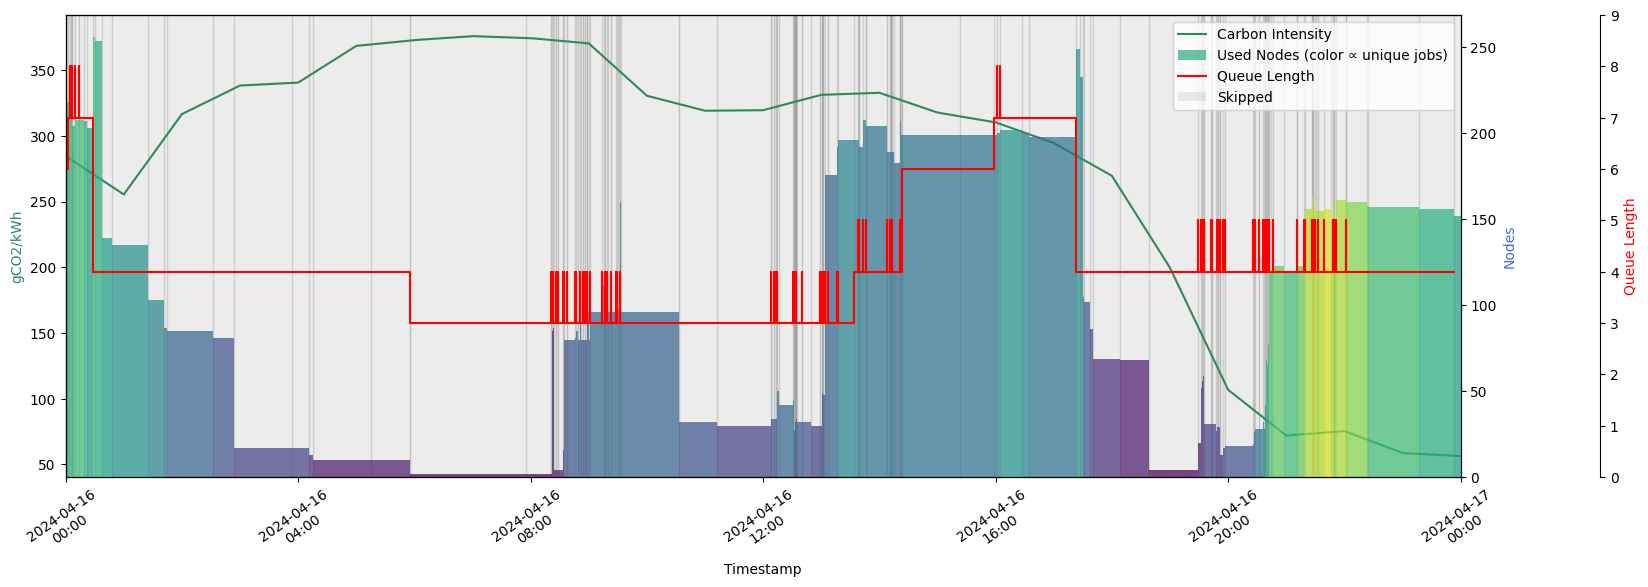

('renderings/seed_3_eta_0.5.png', <Figure size 1800x600 with 3 Axes>)

In [12]:
val = Validation()
val.load_dir(train_and_eval_folder)

seed_3_eta05 = results[3]["trace"]['model']['action_traces']
val.render_timeseries_plot(results[3]["trace"]['model']['action_traces'], start_time = 3600*24*106, end_time = 3600*24*107, name = "seed_3_eta_0.5")

In [17]:
ce = []
for seed in range(1,seeds+1):
    print("Seed: ", seed)
    print(results[seed]["processed_results"]["model"])
    ce.append(results[seed]["processed_results"]["model"]["Carbon Emissions"])

np.mean(ce)

TypeError: can only concatenate list (not "int") to list

In [ ]:
results = best_fit_on_test_workload()

KeyError: 3